In [1]:
!pip install tqdm soundfile torchaudio -q

## 0. Imports & Setup

In [2]:
import os
import sys
import math
import functools
from typing import Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from tqdm import tqdm

try:
    from scipy.signal import windows as scipy_windows
except ImportError:
    scipy_windows = None

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


In [11]:
# ============================================================
# â˜…â˜…â˜… Cáº¤U HÃŒNH Táº I ÄÃ‚Y â€” Äiá»n Ä‘Ãºng paths cá»§a báº¡n â˜…â˜…â˜…
# ============================================================

CHECKPOINT_PATH = r"/kaggle/input/datasets/manh2209/ckpt-epoch-9-16-03-2026/stage2_epoch9_16_03_2026.pt"   
TEST_DIR        = r"/kaggle/input/datasets/minhtu4n/vox-o-vietnamese/VoxVietnameseFullTestSet"  
GT_FILE         = None   
SAMPLE_RATE     = 16000
DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================

device = torch.device(DEVICE)
wav_dir = os.path.join(TEST_DIR, "wav")
gt_path = GT_FILE or os.path.join(TEST_DIR, "test_list_gt_1.csv")

print(f"Device      : {device}")
print(f"Checkpoint  : {CHECKPOINT_PATH}")
print(f"Test dir    : {TEST_DIR}")
print(f"GT file     : {gt_path}")
print(f"Wav dir     : {wav_dir}")
print(f"Wav exists  : {os.path.isdir(wav_dir)}")
print(f"GT exists   : {os.path.isfile(gt_path)}")

Device      : cuda
Checkpoint  : /kaggle/input/datasets/manh2209/ckpt-epoch-9-16-03-2026/stage2_epoch9_16_03_2026.pt
Test dir    : /kaggle/input/datasets/minhtu4n/vox-o-vietnamese/VoxVietnameseFullTestSet
GT file     : /kaggle/input/datasets/minhtu4n/vox-o-vietnamese/VoxVietnameseFullTestSet/test_list_gt_1.csv
Wav dir     : /kaggle/input/datasets/minhtu4n/vox-o-vietnamese/VoxVietnameseFullTestSet/wav
Wav exists  : True
GT exists   : True


In [12]:
# =====================================================================
# ReDimNet Full Architecture (inline, matching notebook finetune)
# Source: https://github.com/IDRnD/ReDimNet (MIT License)
# =====================================================================

# --- Structural Modules ---
class to1d(nn.Module):
    def forward(self, x):
        bs, c, f, t = x.size()
        return x.permute((0, 2, 1, 3)).reshape((bs, c * f, t))

class to2d(nn.Module):
    def __init__(self, f, c):
        super().__init__()
        self.f = f
        self.c = c
    def forward(self, x):
        bs, cf, t = x.size()
        return x.reshape((bs, self.f, self.c, t)).permute((0, 2, 1, 3))
    def extra_repr(self):
        return f"f={self.f},c={self.c}"

class to1d_tfopt(nn.Module):
    def forward(self, x):
        bs, c, t, f = x.size()
        return x.permute((0, 3, 1, 2)).reshape((bs, c * f, t))

class to2d_tfopt(nn.Module):
    def __init__(self, f, c):
        super().__init__()
        self.f = f
        self.c = c
    def forward(self, x):
        bs, cf, t = x.size()
        return x.reshape((bs, self.f, self.c, t)).permute((0, 2, 3, 1))
    def extra_repr(self):
        return f"f={self.f},c={self.c}"

class weigth1d(nn.Module):
    def __init__(self, N, C, sequential=False, requires_grad=True):
        super().__init__()
        self.N = N
        self.sequential = sequential
        self.w = nn.Parameter(torch.zeros(1, N, C, 1), requires_grad=requires_grad)
    def forward(self, xs):
        w = F.softmax(self.w, dim=1)
        if not self.sequential:
            xs = torch.cat([t.unsqueeze(1) for t in xs], dim=1)
            return (w * xs).sum(dim=1)
        else:
            s = torch.zeros_like(xs[0])
            for i, t in enumerate(xs):
                s += t * w[:, i, :, :]
            return s
    def extra_repr(self):
        return f"w={tuple(self.w.size())},sequential={self.sequential}"

# --- LayerNorm ---
class LayerNorm(nn.Module):
    def __init__(self, C, eps=1e-6, data_format="channels_last"):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(C))
        self.bias = nn.Parameter(torch.zeros(C))
        self.eps = eps
        self.data_format = data_format
        self.C = (C,)
    def forward(self, x):
        if self.data_format == "channels_last":
            return F.layer_norm(x, self.C, self.weight, self.bias, self.eps)
        elif self.data_format == "channels_first":
            u = x.mean(1, keepdim=True)
            s = (x - u).pow(2).mean(1, keepdim=True)
            x = (x - u) / torch.sqrt(s + self.eps)
            w, b = self.weight, self.bias
            for _ in range(x.ndim - 2):
                w = w.unsqueeze(-1)
                b = b.unsqueeze(-1)
            return w * x + b

# --- ConvNeXt-like Block ---
_ConvNd = {1: nn.Conv1d, 2: nn.Conv2d}
_BatchNormNd = {1: nn.BatchNorm1d, 2: nn.BatchNorm2d}

class ConvNeXtLikeBlock(nn.Module):
    def __init__(self, C, dim=2, kernel_sizes=[(3,3)], Gdiv=1, padding='same', activation='gelu'):
        super().__init__()
        self.dwconvs = nn.ModuleList([
            _ConvNd[dim](C, C, kernel_size=ks, padding=padding,
                         groups=C // Gdiv if Gdiv is not None else 1)
            for ks in kernel_sizes
        ])
        self.norm = _BatchNormNd[dim](C * len(kernel_sizes))
        self.act = nn.GELU() if activation == 'gelu' else nn.ReLU()
        self.pwconv1 = _ConvNd[dim](C * len(kernel_sizes), C, 1)
    def forward(self, x):
        skip = x
        x = torch.cat([dwconv(x) for dwconv in self.dwconvs], dim=1)
        x = self.act(self.norm(x))
        x = self.pwconv1(x)
        return skip + x

# --- ResNet Basic Block ---
class fwSEBlock(nn.Module):
    def __init__(self, num_freq, num_feats=64):
        super().__init__()
        self.squeeze = nn.Linear(num_freq, num_feats)
        self.exitation = nn.Linear(num_feats, num_freq)
        self.activation = nn.ReLU()
    def forward(self, inputs):
        x = torch.mean(inputs, dim=[1, 3])
        x = self.activation(self.squeeze(x))
        x = torch.sigmoid(self.exitation(x))
        return inputs * x[:, None, :, None]

class ResBasicBlock(nn.Module):
    def __init__(self, inc, outc, num_freq, stride=1, se_channels=64, Gdiv=4, use_fwSE=False):
        super().__init__()
        self.conv1 = nn.Conv2d(inc, inc if Gdiv is not None else outc, kernel_size=3,
                               stride=stride, padding=1, bias=False,
                               groups=inc // Gdiv if Gdiv is not None else 1)
        self.conv1pw = nn.Conv2d(inc, outc, 1) if Gdiv is not None else nn.Identity()
        self.bn1 = nn.BatchNorm2d(outc)
        self.conv2 = nn.Conv2d(outc, outc, kernel_size=3, padding=1, bias=False,
                               groups=outc // Gdiv if Gdiv is not None else 1)
        self.conv2pw = nn.Conv2d(outc, outc, 1) if Gdiv is not None else nn.Identity()
        self.bn2 = nn.BatchNorm2d(outc)
        self.relu = nn.ReLU(inplace=True)
        self.se = fwSEBlock(num_freq, se_channels) if use_fwSE else nn.Identity()
        self.downsample = (nn.Sequential(
            nn.Conv2d(inc, outc, kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm2d(outc)) if outc != inc else nn.Identity())
    def forward(self, x):
        residual = x
        out = self.relu(self.conv1pw(self.conv1(x)))
        out = self.bn1(out)
        out = self.bn2(self.conv2pw(self.conv2(out)))
        out = self.se(out)
        out += self.downsample(residual)
        return self.relu(out)

print("Structural, LayerNorm, ConvNeXt, ResBlock defined.")

Structural, LayerNorm, ConvNeXt, ResBlock defined.


In [13]:
# --- Attention & Transformer ---
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.0, bias=True):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.dropout = dropout
        self.head_dim = embed_dim // num_heads
        self.scaling = self.head_dim ** -0.5
        self.k_proj = nn.Linear(embed_dim, embed_dim, bias=bias)
        self.v_proj = nn.Linear(embed_dim, embed_dim, bias=bias)
        self.q_proj = nn.Linear(embed_dim, embed_dim, bias=bias)
        self.out_proj = nn.Linear(embed_dim, embed_dim, bias=bias)
    def _shape(self, tensor, seq_len, bsz):
        return tensor.view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2).contiguous()
    def forward(self, hidden_states):
        bsz, tgt_len, _ = hidden_states.size()
        query_states = self.q_proj(hidden_states) * self.scaling
        key_states = self._shape(self.k_proj(hidden_states), -1, bsz)
        value_states = self._shape(self.v_proj(hidden_states), -1, bsz)
        proj_shape = (bsz * self.num_heads, -1, self.head_dim)
        query_states = self._shape(query_states, tgt_len, bsz).view(*proj_shape)
        key_states = key_states.view(*proj_shape)
        value_states = value_states.view(*proj_shape)
        attn_weights = F.softmax(torch.bmm(query_states, key_states.transpose(1, 2)), dim=-1)
        attn_probs = F.dropout(attn_weights, p=self.dropout, training=self.training)
        attn_output = torch.bmm(attn_probs, value_states)
        attn_output = attn_output.view(bsz, self.num_heads, tgt_len, self.head_dim)
        attn_output = attn_output.transpose(1, 2).reshape(bsz, tgt_len, self.embed_dim)
        return self.out_proj(attn_output)

class _NewGELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1.0 + torch.tanh(math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x, 3.0))))

class _GELUActivation(nn.Module):
    def forward(self, x):
        return F.gelu(x)

class _FastGELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1.0 + torch.tanh(x * 0.7978845608 * (1.0 + 0.044715 * x * x)))

class _QuickGELU(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(1.702 * x)

class _LinearActivation(nn.Module):
    def forward(self, x):
        return x

_ACT2FN = {
    "gelu": _GELUActivation, "gelu_new": _NewGELU, "gelu_fast": _FastGELU,
    "quick_gelu": _QuickGELU, "linear": _LinearActivation,
    "relu": nn.ReLU, "silu": nn.SiLU, "tanh": nn.Tanh, "sigmoid": nn.Sigmoid,
}

class _FeedForward(nn.Module):
    def __init__(self, hidden_size, intermediate_size, hidden_act='gelu_new',
                 activation_dropout=0.0, hidden_dropout=0.0):
        super().__init__()
        self.intermediate_dropout = nn.Dropout(activation_dropout)
        self.intermediate_dense = nn.Linear(hidden_size, intermediate_size)
        self.intermediate_act_fn = _ACT2FN[hidden_act]()
        self.output_dense = nn.Linear(intermediate_size, hidden_size)
        self.output_dropout = nn.Dropout(hidden_dropout)
    def forward(self, hidden_states):
        hidden_states = self.intermediate_dropout(
            self.intermediate_act_fn(self.intermediate_dense(hidden_states)))
        return self.output_dropout(self.output_dense(hidden_states))

class TransformerEncoderLayer(nn.Module):
    def __init__(self, n_state, n_mlp, n_head, channel_last=False, act='gelu_new',
                 act_do=0.0, att_do=0.0, hid_do=0.0, ln_eps=1e-6):
        super().__init__()
        self.channel_last = channel_last
        self.attention = MultiHeadAttention(embed_dim=n_state, num_heads=n_head, dropout=att_do)
        self.layer_norm = nn.LayerNorm(n_state, eps=ln_eps)
        self.feed_forward = _FeedForward(
            hidden_size=n_state, intermediate_size=n_mlp,
            hidden_act=act, activation_dropout=act_do, hidden_dropout=hid_do)
        self.final_layer_norm = nn.LayerNorm(n_state, eps=ln_eps)
    def forward(self, hidden_states):
        if not self.channel_last:
            hidden_states = hidden_states.permute(0, 2, 1)
        attn_residual = hidden_states
        hidden_states = self.attention(hidden_states)
        hidden_states = self.layer_norm(attn_residual + hidden_states)
        hidden_states = self.final_layer_norm(hidden_states + self.feed_forward(hidden_states))
        if not self.channel_last:
            hidden_states = hidden_states.permute(0, 2, 1)
        return hidden_states

print("Attention & Transformer defined.")

Attention & Transformer defined.


In [14]:
# --- Feature Extraction ---
class NormalizeAudio(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps
    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)
        return (x - x.mean(dim=2, keepdims=True)) / \
               (x.std(dim=2, keepdims=True, unbiased=False) + self.eps)

class PreEmphasis(nn.Module):
    def __init__(self, coef=0.97):
        super().__init__()
        self.coef = coef
        self.register_buffer(
            'flipped_filter', torch.FloatTensor([-coef, 1.]).unsqueeze(0).unsqueeze(0))
    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)
        return F.conv1d(F.pad(x, (1, 0), 'reflect'), self.flipped_filter).squeeze(1)

class FbankAug(nn.Module):
    def __init__(self, freq_mask_width=(0, 8), time_mask_width=(0, 10), freq_start_bin=0):
        super().__init__()
        self.freq_mask_width = freq_mask_width
        self.time_mask_width = time_mask_width
        self.freq_start_bin = freq_start_bin
    def mask_along_axis(self, x, dim):
        original_size = x.shape
        batch, fea, time = x.shape
        D = fea if dim == 1 else time
        width_range = self.freq_mask_width if dim == 1 else self.time_mask_width
        mask_len = torch.randint(width_range[0], width_range[1], (batch, 1), device=x.device).unsqueeze(2)
        mask_pos = torch.randint(self.freq_start_bin, max(1, D - mask_len.max()),
                                 (batch, 1), device=x.device).unsqueeze(2)
        arange = torch.arange(D, device=x.device).view(1, 1, -1)
        mask = ((mask_pos <= arange) * (arange < (mask_pos + mask_len))).any(dim=1)
        mask = mask.unsqueeze(2) if dim == 1 else mask.unsqueeze(1)
        return x.masked_fill_(mask, 0.0).view(*original_size)
    def forward(self, x):
        x = self.mask_along_axis(x, dim=2)
        return self.mask_along_axis(x, dim=1)

class MelBanks(nn.Module):
    def __init__(self, sample_rate=16000, n_fft=512, win_length=400, hop_length=160,
                 f_min=20, f_max=7600, n_mels=80, do_spec_aug=False, norm_signal=False,
                 do_preemph=True, spec_norm='mn', freq_start_bin=0, num_apply_spec_aug=1,
                 freq_mask_width=(0, 8), time_mask_width=(0, 10)):
        super().__init__()
        self.num_apply_spec_aug = num_apply_spec_aug
        self.torchfbank = nn.Sequential(
            NormalizeAudio() if norm_signal else nn.Identity(),
            PreEmphasis() if do_preemph else nn.Identity(),
            torchaudio.transforms.MelSpectrogram(
                sample_rate=sample_rate, n_fft=n_fft, win_length=win_length,
                hop_length=hop_length, f_min=f_min, f_max=f_max, n_mels=n_mels,
                window_fn=torch.hamming_window),
        )
        if spec_norm == 'mn':
            self.spec_norm = lambda x: x - torch.mean(x, dim=-1, keepdim=True)
        elif spec_norm == 'mvn':
            self.spec_norm = lambda x: (x - torch.mean(x, dim=-1, keepdim=True)) / \
                                       (torch.std(x, dim=-1, keepdim=True) + 1e-8)
        elif spec_norm == 'bn':
            self.spec_norm = nn.BatchNorm1d(n_mels)
        else:
            self.spec_norm = lambda x: x
        self.specaug = (FbankAug(freq_start_bin=freq_start_bin, freq_mask_width=freq_mask_width,
                                 time_mask_width=time_mask_width) if do_spec_aug else nn.Identity())
    def forward(self, x):
        xdtype = x.dtype
        x = x.float()
        with torch.no_grad(), torch.amp.autocast('cuda', enabled=False):
            x = self.torchfbank(x) + 1e-6
            x = x.log()
            x = self.spec_norm(x)
            if self.training:
                for _ in range(self.num_apply_spec_aug):
                    x = self.specaug(x)
        return x.to(xdtype)

# --- TF Features ---
class NormalizeAudioTF(nn.Module):
    def __init__(self, eps=1e-10):
        super().__init__()
        self.eps = eps
    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)
        return ((x - x.mean(dim=2, keepdims=True)) /
                (x.std(dim=2, keepdims=True, unbiased=False) + self.eps)).squeeze(1)

class PreEmphasisTF(nn.Module):
    def __init__(self, coef=0.97):
        super().__init__()
        self.coef = coef
        self.register_buffer(
            'flipped_filter', torch.FloatTensor([-coef, 1.]).unsqueeze(0).unsqueeze(0))
    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)
        return F.conv1d(F.pad(x, (1, 0), 'reflect'), self.flipped_filter).squeeze(1)

def _hz2mel(hz):
    return 2595 * np.log10(1 + hz / 700.)

def _get_filterbanks(low_freq=20, high_freq=7600, nfilt=80, nfft=512, samplerate=16000):
    lowmel, highmel = _hz2mel(low_freq), _hz2mel(high_freq)
    melpoints = np.linspace(lowmel, highmel, nfilt + 2)
    lower_edge = melpoints[:-2].reshape(1, -1)
    center = melpoints[1:-1].reshape(1, -1)
    upper_edge = melpoints[2:].reshape(1, -1)
    spec_bins_mel = _hz2mel(np.linspace(0, samplerate // 2, nfft))[1:].reshape(-1, 1)
    lower_slopes = (spec_bins_mel - lower_edge) / (center - lower_edge)
    upper_slopes = (upper_edge - spec_bins_mel) / (upper_edge - center)
    weights = np.maximum(0.0, np.minimum(lower_slopes, upper_slopes))
    return np.vstack([np.zeros((1, nfilt)), weights]).astype('float32')

class SpectralFeaturesTF(nn.Module):
    def __init__(self, frame_length=400, frame_step=160, fft_length=512, sample_rate=16000,
                 window='hann', normalize_spectrogram=False, normalize_signal=False, eps=1e-8,
                 mode='melbanks', low_freq=20, high_freq=7600, num_bins=80, log_mels=True,
                 fft_mode='abs', sqrt_real_imag=False, return_img=False, **kwargs):
        super().__init__()
        self.length = frame_length
        self.shift = frame_step
        self.nfft = fft_length or frame_length
        self.samplerate = sample_rate
        self.sqrt_real_imag = sqrt_real_imag
        self.normalize_spectrogram = normalize_spectrogram
        self.normalize_signal = normalize_signal
        self.eps = eps
        self.features = mode
        self.low_freq = low_freq
        self.high_freq = high_freq
        self.num_bins = num_bins
        self.return_img = return_img
        self.fft_mode = 'abs' if mode in ['melbanks', 'mfcc'] else fft_mode
        self.log_mels = log_mels
        self.window_name = window
        self._build()

    def _build(self):
        win = self.window_name
        if win:
            if win == 'hamming' and scipy_windows is not None:
                win_arr = scipy_windows.hamming(self.length)
            elif win in ['hann', 'hanning']:
                win_arr = np.array([0.5 - 0.5 * np.cos(2 * np.pi * l / (self.length - 1))
                                    for l in range(self.length)])
            elif win == 'sqrt_hann':
                win_arr = np.array([0.5 - 0.5 * np.cos(2 * np.pi * l / (self.length - 1))
                                    for l in range(self.length)]) ** 0.5
            elif win == 'kaiser' and scipy_windows is not None:
                win_arr = scipy_windows.kaiser(self.length)
            else:
                win_arr = np.ones(self.length)
        else:
            win_arr = np.ones(self.length)
        win_arr = win_arr.astype('float32')

        real_kernel = np.asarray([np.cos(2 * np.pi * np.arange(0, self.nfft) * n / self.nfft)
                                  for n in range(self.nfft)]).astype('float32').T
        real_kernel = real_kernel[:self.length, :self.nfft // 2] * win_arr[:, None]
        image_kernel = np.asarray([np.sin(2 * np.pi * np.arange(0, self.nfft) * n / self.nfft)
                                   for n in range(self.nfft)]).astype('float32').T
        image_kernel = image_kernel[:self.length, :self.nfft // 2] * win_arr[:, None]

        self.register_buffer('real_kernel_pt',
                             torch.from_numpy(real_kernel[:, None, :]).permute(2, 1, 0).float())
        self.register_buffer('image_kernel_pt',
                             torch.from_numpy(image_kernel[:, None, :]).permute(2, 1, 0).float())

        if self.features in ['melbanks']:
            fb = _get_filterbanks(nfilt=self.num_bins, nfft=self.nfft // 2,
                                  samplerate=self.samplerate,
                                  low_freq=self.low_freq, high_freq=self.high_freq)
            self.register_buffer('melbanks_pt',
                                 torch.from_numpy(fb[:, :, None]).permute(1, 0, 2).float())

    def forward(self, inputs):
        dtype = inputs.dtype
        inputs = inputs.float()
        if inputs.ndim == 2:
            inputs = inputs.unsqueeze(1)
        if self.normalize_signal:
            inputs = (inputs - inputs.mean(dim=2, keepdims=True)) / \
                     (inputs.std(dim=2, keepdims=True, unbiased=False) + self.eps)
        real_part = F.conv1d(inputs, self.real_kernel_pt, stride=self.shift, padding=self.shift // 2)
        imag_part = F.conv1d(inputs, self.image_kernel_pt, stride=self.shift, padding=self.shift // 2)
        if self.features == 'complex':
            return [real_part, imag_part]
        fft = torch.square(real_part) + torch.square(imag_part)
        if self.sqrt_real_imag:
            fft = torch.sqrt(fft)
        feat = fft.clip(self.eps, 1 / self.eps)
        if self.fft_mode == 'log':
            feat = torch.log(feat)
        if self.features in ['melbanks']:
            mel = F.conv1d(feat, self.melbanks_pt, stride=1, padding=0).clip(self.eps, 1 / self.eps)
            feat = torch.log(mel) if self.log_mels else mel
        if self.normalize_spectrogram:
            feat = (feat - feat.mean(dim=(1, 2), keepdims=True)) / \
                   (feat.std(dim=(1, 2), keepdims=True, unbiased=False) + self.eps)
        return feat[:, None, :, :].to(dtype) if self.return_img else feat.to(dtype)

class TFMelBanks(nn.Module):
    def __init__(self, sample_rate=16000, n_fft=512, win_length=400, hop_length=160,
                 f_min=20, f_max=7600, n_mels=80, do_spec_aug=False, norm_signal=False,
                 do_preemph=True, freq_start_bin=0, freq_mask_width=(0, 8),
                 time_mask_width=(0, 10), eps=1e-8):
        super().__init__()
        self.torchfbank = nn.Sequential(
            NormalizeAudioTF(eps) if norm_signal else nn.Identity(),
            PreEmphasisTF() if do_preemph else nn.Identity(),
            SpectralFeaturesTF(
                frame_length=win_length, frame_step=hop_length, fft_length=n_fft,
                sample_rate=sample_rate, window='hamming', normalize_spectrogram=False,
                normalize_signal=False, eps=eps, mode='melbanks', low_freq=f_min,
                high_freq=f_max, num_bins=n_mels, log_mels=False, fft_mode='abs',
                sqrt_real_imag=False, return_img=False))
        self.eps = eps
        self.specaug = (FbankAug(freq_start_bin=freq_start_bin, freq_mask_width=freq_mask_width,
                                 time_mask_width=time_mask_width) if do_spec_aug else nn.Identity())
    def forward(self, x):
        xdtype = x.dtype
        x = x.float()
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=False):
            x = self.torchfbank(x) + self.eps
            x = x.log()
            x = x - torch.mean(x, dim=-1, keepdim=True)
            if self.training:
                x = self.specaug(x)
        return x.to(xdtype)

class TFSpectrogram(nn.Module):
    def __init__(self, sample_rate=16000, n_fft=512, win_length=400, hop_length=160,
                 f_min=20, f_max=7600, n_mels=80, window='hamming',
                 normalize_spectrogram=False, normalize_signal=False, mode='fft',
                 fft_mode='abs', pool_freqs=(2, 1), do_spec_aug=False, norm_signal=False,
                 do_preemph=True, freq_start_bin=0, num_apply_spec_aug=1,
                 freq_mask_width=(0, 8), time_mask_width=(0, 10), eps=1e-8):
        super().__init__()
        self.num_apply_spec_aug = num_apply_spec_aug
        self.spectrogram = nn.Sequential(
            NormalizeAudioTF() if norm_signal else nn.Identity(),
            PreEmphasisTF() if do_preemph else nn.Identity(),
            SpectralFeaturesTF(
                frame_length=win_length, frame_step=hop_length, fft_length=n_fft,
                sample_rate=sample_rate, window=window, eps=eps, mode=mode,
                low_freq=f_min, high_freq=f_max, num_bins=n_mels,
                normalize_spectrogram=False, normalize_signal=False,
                fft_mode='abs', log_mels=False, sqrt_real_imag=False, return_img=False))
        self.pool_freq = nn.AvgPool2d(pool_freqs, stride=pool_freqs) if pool_freqs is not None else nn.Identity()
        self.eps = eps
        self.specaug = (FbankAug(freq_start_bin=freq_start_bin, freq_mask_width=freq_mask_width,
                                 time_mask_width=time_mask_width) if do_spec_aug else nn.Identity())
    def forward(self, x):
        xdtype = x.dtype
        x = x.float()
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=False):
            x = self.spectrogram(x) + self.eps
            x = x.log()
            x = x - torch.mean(x, dim=-1, keepdim=True)
            if self.training:
                for _ in range(self.num_apply_spec_aug):
                    x = self.specaug(x)
            x = self.pool_freq(x.unsqueeze(1))
        return x.to(xdtype)

print("Feature extraction defined (MelBanks, TFMelBanks, TFSpectrogram).")

Feature extraction defined (MelBanks, TFMelBanks, TFSpectrogram).


In [15]:
# --- Pooling Layers ---
class TAP(nn.Module):
    def __init__(self, in_dim=0, **kwargs):
        super().__init__()
        self.in_dim = in_dim
    def forward(self, x):
        if x.ndim == 3: return x.mean(dim=-1)
        elif x.ndim == 4: return x.mean(dim=(-1, -2)).flatten(start_dim=1)
    def get_out_dim(self):
        self.out_dim = self.in_dim
        return self.out_dim

class TMAP(nn.Module):
    def __init__(self, in_dim=0, **kwargs):
        super().__init__()
        self.in_dim = in_dim
    def forward(self, x):
        if x.ndim == 3: return torch.max(x, dim=-1)[0] + torch.mean(x, dim=-1)
        elif x.ndim == 4: return torch.max(torch.max(x, dim=-1)[0], dim=-1)[0] + torch.mean(x, dim=(-1, -2))
    def get_out_dim(self):
        self.out_dim = self.in_dim
        return self.out_dim

class TSDP(nn.Module):
    def __init__(self, in_dim=0, **kwargs):
        super().__init__()
        self.in_dim = in_dim
    def forward(self, x):
        return torch.sqrt(torch.var(x, dim=-1) + 1e-7).flatten(start_dim=1)
    def get_out_dim(self):
        self.out_dim = self.in_dim
        return self.out_dim

class TSTP(nn.Module):
    def __init__(self, in_dim=0, **kwargs):
        super().__init__()
        self.in_dim = in_dim
    def forward(self, x):
        pooling_mean = x.mean(dim=-1).flatten(start_dim=1)
        pooling_std = torch.sqrt(torch.var(x, dim=-1) + 1e-7).flatten(start_dim=1)
        return torch.cat((pooling_mean, pooling_std), 1)
    def get_out_dim(self):
        self.out_dim = self.in_dim * 2
        return self.out_dim

class ASTP(nn.Module):
    def __init__(self, in_dim, bottleneck_dim=128, global_context_att=False, **kwargs):
        super().__init__()
        self.in_dim = in_dim
        self.global_context_att = global_context_att
        self.linear1 = nn.Conv1d(in_dim * 3 if global_context_att else in_dim,
                                 bottleneck_dim, kernel_size=1)
        self.linear2 = nn.Conv1d(bottleneck_dim, in_dim, kernel_size=1)
    def forward(self, x):
        if x.ndim == 4:
            x = x.reshape(x.shape[0], x.shape[1] * x.shape[2], x.shape[3])
        assert x.ndim == 3
        if self.global_context_att:
            context_mean = torch.mean(x, dim=-1, keepdim=True).expand_as(x)
            context_std = torch.sqrt(torch.var(x, dim=-1, keepdim=True) + 1e-7).expand_as(x)
            x_in = torch.cat((x, context_mean, context_std), dim=1)
        else:
            x_in = x
        alpha = torch.softmax(self.linear2(torch.tanh(self.linear1(x_in))), dim=2)
        mean = torch.sum(alpha * x, dim=2)
        var = torch.sum(alpha * (x ** 2), dim=2) - mean ** 2
        std = torch.sqrt(var.clamp(min=1e-7))
        return torch.cat([mean, std], dim=1)
    def get_out_dim(self):
        self.out_dim = 2 * self.in_dim
        return self.out_dim

class MHASTP(nn.Module):
    def __init__(self, in_dim, layer_num=2, head_num=2, d_s=1, bottleneck_dim=64, **kwargs):
        super().__init__()
        self.in_dim = in_dim
        self.head_num = head_num
        d_model = in_dim // head_num
        channel_dims = [bottleneck_dim] * (layer_num + 1)
        d_s = d_model if d_s > 1 else 1
        channel_dims[0], channel_dims[-1] = d_model, d_s
        heads_att_trans = []
        for _ in range(head_num):
            att_trans = nn.Sequential()
            for i in range(layer_num - 1):
                att_trans.add_module(f'att_{i}', nn.Conv1d(channel_dims[i], channel_dims[i + 1], 1, 1))
                att_trans.add_module(f'tanh{i}', nn.Tanh())
            att_trans.add_module(f'att_{layer_num - 1}',
                                nn.Conv1d(channel_dims[layer_num - 1], channel_dims[layer_num], 1, 1))
            heads_att_trans.append(att_trans)
        self.heads_att_trans = nn.ModuleList(heads_att_trans)
    def forward(self, x):
        if x.ndim == 4:
            x = x.reshape(x.shape[0], x.shape[1] * x.shape[2], x.shape[3])
        assert x.ndim == 3
        chunks = torch.chunk(x, self.head_num, 1)
        chunks_out = []
        for i, layer in enumerate(self.heads_att_trans):
            alpha = F.softmax(layer(chunks[i]), dim=-1)
            mean = torch.sum(alpha * chunks[i], dim=2)
            var = torch.sum(alpha * chunks[i] ** 2, dim=2) - mean ** 2
            std = torch.sqrt(var.clamp(min=1e-7))
            chunks_out.append(torch.cat((mean, std), dim=1))
        return torch.cat(chunks_out, dim=1)
    def get_out_dim(self):
        self.out_dim = 2 * self.in_dim
        return self.out_dim

class MQMHASTP(nn.Module):
    def __init__(self, in_dim, layer_num=2, query_num=2, head_num=8, d_s=2,
                 bottleneck_dim=64, **kwargs):
        super().__init__()
        self.in_dim = in_dim
        self.query_num = query_num
        self.n_query = nn.ModuleList([
            MHASTP(in_dim, layer_num=layer_num, head_num=head_num,
                   d_s=d_s, bottleneck_dim=bottleneck_dim)
            for _ in range(query_num)])
    def forward(self, x):
        if x.ndim == 4:
            x = x.reshape(x.shape[0], x.shape[1] * x.shape[2], x.shape[3])
        assert x.ndim == 3
        return torch.cat([layer(x) for layer in self.n_query], dim=-1)
    def get_out_dim(self):
        self.out_dim = self.in_dim * 2 * self.query_num
        return self.out_dim

_POOLING_LAYERS = {
    'TAP': TAP, 'TMAP': TMAP, 'TSDP': TSDP, 'TSTP': TSTP,
    'ASTP': ASTP, 'MHASTP': MHASTP, 'MQMHASTP': MQMHASTP,
}

print("Pooling layers defined (TAP, TSTP, ASTP, MHASTP, MQMHASTP).")

Pooling layers defined (TAP, TSTP, ASTP, MHASTP, MQMHASTP).


In [16]:
# --- ReDimNet Core ---
class ConvBlock2d(nn.Module):
    def __init__(self, c, f, block_type="convnext_like", Gdiv=1):
        super().__init__()
        if block_type == "convnext_like":
            self.conv_block = ConvNeXtLikeBlock(c, dim=2, kernel_sizes=[(3, 3)],
                                                Gdiv=Gdiv, padding='same', activation='gelu')
        elif block_type == "convnext_like_relu":
            self.conv_block = ConvNeXtLikeBlock(c, dim=2, kernel_sizes=[(3, 3)],
                                                Gdiv=Gdiv, padding='same', activation='relu')
        elif block_type == "basic_resnet":
            self.conv_block = ResBasicBlock(c, c, f, stride=1,
                                           se_channels=min(64, max(c, 32)), Gdiv=Gdiv, use_fwSE=False)
        elif block_type == "basic_resnet_fwse":
            self.conv_block = ResBasicBlock(c, c, f, stride=1,
                                           se_channels=min(64, max(c, 32)), Gdiv=Gdiv, use_fwSE=True)
    def forward(self, x):
        return self.conv_block(x)

class PosEncConv(nn.Module):
    def __init__(self, C, ks, groups=None):
        super().__init__()
        assert ks % 2 == 1
        self.conv = nn.Conv1d(C, C, ks, padding=ks // 2, groups=C if groups is None else groups)
        self.norm = LayerNorm(C, eps=1e-6, data_format="channels_first")
    def forward(self, x):
        return x + self.norm(self.conv(x))

class TimeContextBlock1d(nn.Module):
    def __init__(self, C, hC, pos_ker_sz=59, block_type='att',
                 red_dim_conv=None, exp_dim_conv=None):
        super().__init__()
        self.red_dim_conv = nn.Sequential(
            nn.Conv1d(C, hC, 1),
            LayerNorm(hC, eps=1e-6, data_format="channels_first"))
        if block_type == 'fc':
            self.tcm = nn.Sequential(
                nn.Conv1d(hC, hC * 2, 1),
                LayerNorm(hC * 2, eps=1e-6, data_format="channels_first"),
                nn.GELU(),
                nn.Conv1d(hC * 2, hC, 1))
        elif block_type == 'conv':
            self.tcm = nn.Sequential(*[
                ConvNeXtLikeBlock(hC, dim=1, kernel_sizes=[7, 15, 31], Gdiv=1, padding='same')
                for _ in range(4)])
        elif block_type == 'att':
            self.tcm = nn.Sequential(
                PosEncConv(hC, ks=pos_ker_sz, groups=hC),
                TransformerEncoderLayer(n_state=hC, n_mlp=hC * 2, n_head=4))
        elif block_type == 'conv+att':
            self.tcm = nn.Sequential(
                ConvNeXtLikeBlock(hC, dim=1, kernel_sizes=[7], Gdiv=1, padding='same'),
                ConvNeXtLikeBlock(hC, dim=1, kernel_sizes=[19], Gdiv=1, padding='same'),
                ConvNeXtLikeBlock(hC, dim=1, kernel_sizes=[31], Gdiv=1, padding='same'),
                ConvNeXtLikeBlock(hC, dim=1, kernel_sizes=[59], Gdiv=1, padding='same'),
                TransformerEncoderLayer(n_state=hC, n_mlp=hC, n_head=4))
        self.exp_dim_conv = nn.Conv1d(hC, C, 1)
    def forward(self, x):
        return x + self.exp_dim_conv(self.tcm(self.red_dim_conv(x)))

class ReDimNet(nn.Module):
    def __init__(self, F=72, C=12, block_1d_type="att", block_2d_type="convnext_like",
                 stages_setup=[
                     (1, 2, 1, [(3, 3)], None), (2, 3, 1, [(3, 3)], None),
                     (3, 4, 1, [(3, 3)], 8), (2, 5, 1, [(3, 3)], 8),
                     (1, 5, 1, [(7, 1)], 8), (2, 3, 1, [(3, 3)], 8),
                 ],
                 group_divisor=1, out_channels=512, feat_agg_dropout=0.0,
                 return_2d_output=False, return_all_outputs=False,
                 offset_fm_weights=0, is_subnet=False):
        super().__init__()
        self.F = F
        self.C = C
        self.block_1d_type = block_1d_type
        self.block_2d_type = block_2d_type
        self.stages_setup = stages_setup
        self.feat_agg_dropout = feat_agg_dropout
        self.return_2d_output = return_2d_output
        self.is_subnet = is_subnet
        self.offset_fm_weights = offset_fm_weights
        self.return_all_outputs = return_all_outputs
        self.build(F, C, stages_setup, group_divisor, out_channels, offset_fm_weights, is_subnet)

    def build(self, F, C, stages_setup, group_divisor, out_channels, offset_fm_weights, is_subnet):
        self.F = F
        self.C = C
        c = C
        f = F
        self.num_stages = len(stages_setup)

        if not is_subnet:
            self.stem = nn.Sequential(
                nn.Conv2d(1, int(c), kernel_size=3, stride=1, padding='same'),
                LayerNorm(int(c), eps=1e-6, data_format="channels_first"),
                to1d())
        else:
            self.stem = nn.Sequential(
                weigth1d(N=offset_fm_weights, C=F * C),
                to2d(f=F, c=C),
                nn.Conv2d(C, C, kernel_size=3, stride=1, padding='same'),
                LayerNorm(C, eps=1e-6, data_format="channels_first"),
                to1d())

        Block1d = functools.partial(TimeContextBlock1d, block_type=self.block_1d_type)
        Block2d = functools.partial(ConvBlock2d, block_type=self.block_2d_type)

        self.stages_cfs = []
        num_feats_to_weight = 0
        for stage_ind, (stride, num_blocks, conv_exp, kernel_sizes, att_block_red) in enumerate(stages_setup):
            assert stride in [1, 2, 3]
            num_feats_to_weight = offset_fm_weights + stage_ind + 1
            layers = [
                weigth1d(N=num_feats_to_weight, C=F * C if num_feats_to_weight > 1 else 1,
                         requires_grad=num_feats_to_weight > 1),
                to2d(f=f, c=c),
                nn.Conv2d(int(c), int(stride * c * conv_exp),
                          kernel_size=(stride, 1), stride=(stride, 1), padding=0, groups=1),
            ]
            self.stages_cfs.append((c, f))
            c = stride * c
            assert f % stride == 0
            f = f // stride
            for _ in range(num_blocks):
                layers.append(Block2d(c=int(c * conv_exp), f=f, Gdiv=group_divisor))
            if conv_exp != 1:
                _gdiv = group_divisor
                layers.append(nn.Sequential(
                    nn.Conv2d(int(c * conv_exp), c, kernel_size=(3, 3), stride=1, padding='same',
                              groups=c // _gdiv if _gdiv is not None else 1),
                    nn.BatchNorm2d(c, eps=1e-6),
                    nn.ReLU() if (('relu' in self.block_1d_type) and ('relu' in self.block_2d_type)) else nn.GELU(),
                    nn.Conv2d(c, c, 1)))
            layers.append(to1d())
            if att_block_red is not None:
                layers.append(Block1d(C * F, hC=(C * F) // att_block_red))
            setattr(self, f'stage{stage_ind}', nn.Sequential(*layers))

        num_feats_to_weight_fin = offset_fm_weights + len(stages_setup) + 1
        self.fin_wght1d = weigth1d(N=num_feats_to_weight_fin, C=F * C,
                                   requires_grad=num_feats_to_weight > 1)
        if out_channels is not None:
            self.mfa = nn.Sequential(
                nn.Conv1d(self.F * self.C, out_channels, kernel_size=1, padding='same'),
                nn.BatchNorm1d(out_channels, affine=True))
        else:
            self.mfa = nn.Identity()
        self.fin_to2d = to2d(f=f, c=c) if self.return_2d_output else nn.Identity()

    def run_stage(self, prev_outs_1d, stage_ind):
        return getattr(self, f'stage{stage_ind}')(prev_outs_1d)

    def forward(self, inp):
        if not self.is_subnet:
            x = self.stem(inp)
            outputs_1d = [x]
        else:
            assert isinstance(inp, list)
            outputs_1d = list(inp)
            x = self.stem(inp)
            outputs_1d.append(x)
        for stage_ind in range(self.num_stages):
            outputs_1d.append(F.dropout(self.run_stage(outputs_1d, stage_ind),
                                        p=self.feat_agg_dropout, training=self.training))
        x = self.fin_wght1d(outputs_1d)
        outputs_1d.append(x)
        x = self.mfa(self.fin_to2d(x))
        return (x, outputs_1d) if self.return_all_outputs else x


class ReDimNetWrap(nn.Module):
    def __init__(self,
                 F=72, C=16,
                 block_1d_type="att", block_2d_type="convnext_like",
                 stages_setup=[
                     (1, 2, 1, [(3, 3)], 12), (2, 2, 1, [(3, 3)], 12),
                     (1, 3, 1, [(3, 3)], 12), (2, 4, 1, [(3, 3)], 8),
                     (1, 4, 1, [(3, 3)], 8), (2, 4, 1, [(3, 3)], 4),
                 ],
                 group_divisor=4, out_channels=None,
                 embed_dim=192, num_classes=None, class_dropout=0.0,
                 feat_agg_dropout=0.0, head_activation=None, hop_length=160,
                 pooling_func='ASTP', feat_type='pt', global_context_att=False,
                 emb_bn=False,
                 spec_params=dict(do_spec_aug=False, freq_mask_width=(0, 6),
                                  time_mask_width=(0, 8)),
                 return_all_outputs=False, tf_optimized_arch=False):
        super().__init__()
        self.return_all_outputs = return_all_outputs
        self.tf_optimized_arch = tf_optimized_arch

        self.backbone = ReDimNet(
            F, C, block_1d_type, block_2d_type, stages_setup, group_divisor,
            out_channels, feat_agg_dropout=feat_agg_dropout, return_2d_output=False,
            return_all_outputs=return_all_outputs, offset_fm_weights=0, is_subnet=False)

        if feat_type in ['pt', 'pt_mel']:
            self.spec = MelBanks(n_mels=F, hop_length=hop_length, **spec_params)
        elif feat_type in ['tf', 'tf_mel']:
            self.spec = TFMelBanks(n_mels=F, hop_length=hop_length, **spec_params)
        elif feat_type == 'tf_spec':
            self.spec = TFSpectrogram(**spec_params)

        if out_channels is None:
            out_channels = C * F
        self.pool = _POOLING_LAYERS[pooling_func](
            in_dim=out_channels, global_context_att=global_context_att)
        self.pool_out_dim = self.pool.get_out_dim()
        self.bn = nn.BatchNorm1d(self.pool_out_dim)
        self.linear = nn.Linear(self.pool_out_dim, embed_dim)
        self.emb_bn = emb_bn
        self.bn2 = nn.BatchNorm1d(embed_dim) if emb_bn else None
        if num_classes is not None:
            self.cls_head = nn.Sequential(
                nn.ReLU(inplace=False),
                nn.Dropout(p=class_dropout, inplace=False),
                nn.Linear(embed_dim, num_classes),
                eval(head_activation) if head_activation is not None else nn.Identity())
        else:
            self.cls_head = None

    def forward(self, x):
        x = self.spec(x)
        if self.tf_optimized_arch:
            x = x.permute(0, 2, 1)
        if x.ndim == 3:
            x = x.unsqueeze(1)
        if self.return_all_outputs:
            out, all_outs_1d = self.backbone(x)
        else:
            out = self.backbone(x)
        out = self.linear(self.bn(self.pool(out)))
        if self.bn2 is not None:
            out = self.bn2(out)
        if self.cls_head is not None:
            out = self.cls_head(out)
        return (out, all_outs_1d) if self.return_all_outputs else out


print("ReDimNet full architecture loaded inline.")

ReDimNet full architecture loaded inline.


## 3. Evaluation Functions â€” EER, minDCF, Embedding Extraction

In [17]:
def compute_eer(scores: np.ndarray, labels: np.ndarray) -> Tuple[float, float]:
    """Compute Equal Error Rate (EER) and threshold."""
    sorted_indices = np.argsort(scores)
    sorted_scores = scores[sorted_indices]
    sorted_labels = labels[sorted_indices]

    num_target = np.sum(labels == 1)
    num_nontarget = np.sum(labels == 0)

    fnr = np.cumsum(sorted_labels == 1) / max(num_target, 1)
    fpr = 1.0 - np.cumsum(sorted_labels == 0) / max(num_nontarget, 1)

    diff = fnr - fpr
    idx = np.argmin(np.abs(diff))
    eer = 0.5 * (fnr[idx] + fpr[idx])
    threshold = sorted_scores[idx]
    return eer, threshold


def compute_min_dcf(scores: np.ndarray, labels: np.ndarray,
                    p_target: float = 0.01, c_miss: float = 1.0,
                    c_fa: float = 1.0) -> float:
    """Compute minimum Detection Cost Function (minDCF)."""
    sorted_indices = np.argsort(scores)
    sorted_labels = labels[sorted_indices]

    num_target = np.sum(labels == 1)
    num_nontarget = np.sum(labels == 0)

    fnr = np.cumsum(sorted_labels == 1) / max(num_target, 1)
    fpr = 1.0 - np.cumsum(sorted_labels == 0) / max(num_nontarget, 1)

    dcf = c_miss * fnr * p_target + c_fa * fpr * (1 - p_target)
    min_dcf = np.min(dcf)
    min_c = min(c_miss * p_target, c_fa * (1 - p_target))
    return min_dcf / max(min_c, 1e-8)


@torch.no_grad()
def extract_embedding(model, wav_path: str, sample_rate: int, device: torch.device) -> torch.Tensor:
    """Extract L2-normalized embedding from a single wav file (full-length)."""
    waveform, sr = torchaudio.load(wav_path)
    if sr != sample_rate:
        waveform = torchaudio.functional.resample(waveform, sr, sample_rate)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    # (1, 1, T)
    waveform = waveform.unsqueeze(0).to(device)

    with torch.amp.autocast("cuda", dtype=torch.float16, enabled=device.type == "cuda"):
        emb = model(waveform)  # (1, embed_dim)

    emb = F.normalize(emb.float().cpu(), p=2, dim=1).squeeze(0)  # (embed_dim,)
    return emb


def parse_gt_csv(gt_path: str):
    """
    Parse test_list_gt.csv with format:
        label<TAB>wav/audio00001.wav<TAB>wav/audio00002.wav

    Returns: list of (label, utt1_relative, utt2_relative)
    """
    trials = []
    seen_pairs = set() # Sử dụng set để theo dõi các cặp đã duyệt qua
    
    bom = chr(65279)
    with open(gt_path, "r", encoding="utf-8-sig") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) != 3:
                # Try comma-separated
                parts = line.split(",")
            if len(parts) != 3:
                # Try space-separated
                parts = line.split()
            if len(parts) != 3:
                continue
            # Strip whitespace, quotes, and a possible BOM on the first field.
            parts = [p.strip().strip('"').strip("'").lstrip(bom) for p in parts]
            try:
                label = int(parts[0])
            except ValueError:
                continue
                
            utt1 = parts[1]
            utt2 = parts[2]
            
            # Sắp xếp utt1 và utt2 để gom nhóm chung các cặp dạng (A, B) và (B, A)
            pair_identifier = tuple(sorted([utt1, utt2]))
            
            # Nếu cặp này chưa xuất hiện trong tập kiểm tra thì mới thêm vào danh sách trials
            if pair_identifier not in seen_pairs:
                seen_pairs.add(pair_identifier)
                trials.append((label, utt1, utt2))
                
    return trials


print("Evaluation functions defined: compute_eer, compute_min_dcf, extract_embedding, parse_gt_csv")

Evaluation functions defined: compute_eer, compute_min_dcf, extract_embedding, parse_gt_csv


## 4. Load Checkpoint

In [18]:
def load_model_from_checkpoint(checkpoint_path: str, device: torch.device) -> ReDimNetWrap:
    """
    Load finetuned ReDimNet-B6 from checkpoint.
    
    The checkpoint is saved by the notebook's training loop and contains
    'model_state_dict'. The model architecture is reconstructed by first
    loading the pretrained config from torch.hub, then overriding the weights.
    """
    print(f"Loading checkpoint: {checkpoint_path}")
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)

    # Try to get model config from checkpoint if available
    if "model_config" in ckpt:
        model_config = ckpt["model_config"]
        model = ReDimNetWrap(**model_config)
    else:
        # Reconstruct via torch.hub to get the correct architecture config
        print("Reconstructing model architecture via torch.hub (ReDimNet-B6, ft_lm, vox2)...")
        model = torch.hub.load(
            'IDRnD/ReDimNet', 'ReDimNet',
            model_name='b6', train_type='ft_lm', dataset='vox2',
        )

    # Remove cls_head if present (we only need embeddings)
    if hasattr(model, 'cls_head') and model.cls_head is not None:
        model.cls_head = None

    # Load finetuned weights
    state_dict = ckpt.get("model_state_dict", ckpt.get("state_dict", ckpt))
    # Filter out cls_head keys
    state_dict = {k: v for k, v in state_dict.items() if not k.startswith("cls_head")}
    load_result = model.load_state_dict(state_dict, strict=False)
    if load_result.missing_keys:
        print(f"  Missing keys (expected if cls_head removed): {load_result.missing_keys}")
    if load_result.unexpected_keys:
        print(f"  Unexpected keys: {load_result.unexpected_keys}")

    model = model.to(device)
    model.eval()

    num_params = sum(p.numel() for p in model.parameters()) / 1e6
    epoch = ckpt.get("epoch", "?")
    train_loss = ckpt.get("train_loss", "?")
    print(f"  Loaded epoch {epoch}, train_loss={train_loss}, params={num_params:.2f}M")
    return model


# ===== Load Model =====
model = load_model_from_checkpoint(CHECKPOINT_PATH, device)

Loading checkpoint: /kaggle/input/datasets/manh2209/ckpt-epoch-9-16-03-2026/stage2_epoch9_16_03_2026.pt
Reconstructing model architecture via torch.hub (ReDimNet-B6, ft_lm, vox2)...


/usr/local/lib/python3.12/dist-packages/torch/hub.py:335: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(


Downloading: "https://github.com/IDRnD/ReDimNet/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/IDRnD/ReDimNet/releases/download/latest/b6-vox2-ft_lm.pt" to /root/.cache/torch/hub/checkpoints/b6-vox2-ft_lm.pt


100%|██████████| 57.9M/57.9M [00:00<00:00, 85.3MB/s]


  Loaded epoch 9, train_loss=1.3476456919949302, params=15.02M


## 5. Parse Ground Truth & Extract Embeddings

In [19]:
# ===== Parse Ground Truth =====
trials = parse_gt_csv(gt_path)
print(f"Loaded {len(trials)} trial pairs from {gt_path}")

num_pos = sum(1 for l, _, _ in trials if l == 1)
num_neg = sum(1 for l, _, _ in trials if l == 0)
print(f"  Positive pairs: {num_pos}")
print(f"  Negative pairs: {num_neg}")

# Preview first 5 trials
print("\nFirst 5 trials:")
for i, (label, u1, u2) in enumerate(trials[:5]):
    print(f"  [{i}] label={label}  {u1}  <->  {u2}")

Loaded 8887 trial pairs from /kaggle/input/datasets/minhtu4n/vox-o-vietnamese/VoxVietnameseFullTestSet/test_list_gt_1.csv
  Positive pairs: 2604
  Negative pairs: 6283

First 5 trials:
  [0] label=1  wav/audio00001.wav  <->  wav/audio00002.wav
  [1] label=1  wav/audio00003.wav  <->  wav/audio00004.wav
  [2] label=1  wav/audio00005.wav  <->  wav/audio00006.wav
  [3] label=1  wav/audio00007.wav  <->  wav/audio00008.wav
  [4] label=1  wav/audio00009.wav  <->  wav/audio00010.wav


In [20]:
# ===== Collect unique utterances =====
unique_utts = set()
for _, utt1, utt2 in trials:
    unique_utts.add(utt1)
    unique_utts.add(utt2)
unique_utts = sorted(unique_utts)
print(f"Unique utterances to process: {len(unique_utts)}")

# ===== Resolve file paths =====
utt_paths = {}
missing = []
for utt_rel in unique_utts:
    wav_path = os.path.join(TEST_DIR, utt_rel)
    if not os.path.isfile(wav_path):
        alt_path = os.path.join(wav_dir, os.path.basename(utt_rel))
        if os.path.isfile(alt_path):
            wav_path = alt_path
        else:
            missing.append(utt_rel)
            continue
    utt_paths[utt_rel] = wav_path

if missing:
    print(f"WARNING: {len(missing)} files not found")
    for m in missing[:5]:
        print(f"  - {m}")
print(f"Files resolved: {len(utt_paths)}")

# ===== Config =====
MAX_BATCH_SIZE = 16
# Max total samples in a batch (prevents OOM from long-audio batches)
# 16000 * 12 * 16 = ~12s avg * 16 items â€” safe cho 15GB GPU
MAX_BATCH_TOTAL_SAMPLES = 16000 * 12 * MAX_BATCH_SIZE

def load_wav(path, sr_target):
    waveform, sr = torchaudio.load(path)
    if sr != sr_target:
        waveform = torchaudio.functional.resample(waveform, sr, sr_target)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    return waveform.squeeze(0)  # (T,)

# ===== Sort by duration â†’ similar-length batches â†’ less padding waste =====
print("\nScanning audio lengths (by file size as proxy)...")
utt_keys = list(utt_paths.keys())
utt_lens = []
for key in utt_keys:
    utt_lens.append(os.path.getsize(utt_paths[key]))

order = np.argsort(utt_lens)
sorted_keys = [utt_keys[i] for i in order]
sorted_lens = [utt_lens[i] for i in order]

# ===== Build dynamic batches =====
batches = []
cur_batch = []
cur_max_len = 0

for key, length in zip(sorted_keys, sorted_lens):
    new_max_len = max(cur_max_len, length)
    new_total = (len(cur_batch) + 1) * new_max_len  # padded tensor size
    if cur_batch and (len(cur_batch) >= MAX_BATCH_SIZE or new_total > MAX_BATCH_TOTAL_SAMPLES):
        batches.append(cur_batch)
        cur_batch = [key]
        cur_max_len = length
    else:
        cur_batch.append(key)
        cur_max_len = new_max_len
if cur_batch:
    batches.append(cur_batch)

batch_sizes = [len(b) for b in batches]
print(f"Created {len(batches)} batches â€” sizes: min={min(batch_sizes)}, "
      f"max={max(batch_sizes)}, median={sorted(batch_sizes)[len(batch_sizes)//2]}")

# ===== Run batched inference with OOM fallback =====
print(f"\nExtracting embeddings...")
emb_dict = {}

@torch.no_grad()
def extract_single(model, wav_path, sr, dev):
    """Fallback: single-file inference when a batch OOMs."""
    wav = load_wav(wav_path, sr).unsqueeze(0).unsqueeze(0).to(dev)
    with torch.amp.autocast("cuda", dtype=torch.float16, enabled=dev.type == "cuda"):
        emb = model(wav)
    return F.normalize(emb.float().cpu(), p=2, dim=1).squeeze(0)

with torch.no_grad():
    for batch_keys in tqdm(batches, desc="Extracting"):
        wavs = [load_wav(utt_paths[k], SAMPLE_RATE) for k in batch_keys]
        max_len = max(w.shape[0] for w in wavs)
        padded = torch.zeros(len(wavs), max_len)
        for i, w in enumerate(wavs):
            padded[i, :w.shape[0]] = w

        try:
            padded = padded.unsqueeze(1).to(device)  # (B, 1, T)
            with torch.amp.autocast("cuda", dtype=torch.float16, enabled=device.type == "cuda"):
                embs = model(padded)
            embs = F.normalize(embs.float().cpu(), p=2, dim=1)
            for i, key in enumerate(batch_keys):
                emb_dict[key] = embs[i]
            del padded, embs
        except torch.cuda.OutOfMemoryError:
            del padded
            torch.cuda.empty_cache()
            for key in batch_keys:
                if key not in emb_dict:
                    emb_dict[key] = extract_single(model, utt_paths[key], SAMPLE_RATE, device)
            torch.cuda.empty_cache()

print(f"\nExtracted {len(emb_dict)} embeddings")

Unique utterances to process: 17774
Files resolved: 17774

Scanning audio lengths (by file size as proxy)...
Created 1329 batches â€” sizes: min=1, max=16, median=16

Extracting embeddings...


Extracting: 100%|██████████| 1329/1329 [33:59<00:00,  1.53s/it]


Extracted 17774 embeddings


## 6. Compute Scores & Evaluate EER

In [21]:
# ===== Compute cosine similarity scores =====
print("Computing cosine similarity scores...")
scores_list = []
labels_list = []
skipped = 0

for label, utt1, utt2 in trials:
    if utt1 not in emb_dict or utt2 not in emb_dict:
        skipped += 1
        continue
    score = (emb_dict[utt1] @ emb_dict[utt2]).item()
    scores_list.append(score)
    labels_list.append(label)

if skipped > 0:
    print(f"Skipped {skipped} trials (missing embeddings)")

scores_arr = np.array(scores_list)
labels_arr = np.array(labels_list)

# ===== Compute EER & minDCF =====
eer, threshold = compute_eer(scores_arr, labels_arr)
min_dcf = compute_min_dcf(scores_arr, labels_arr)

print("\n" + "=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)
print(f"  Checkpoint : {CHECKPOINT_PATH}")
print(f"  Test set   : {TEST_DIR}")
print(f"  Num trials : {len(scores_list)} (pos={num_pos}, neg={num_neg})")
print(f"  EER        : {eer * 100:.4f}%")
print(f"  Threshold  : {threshold:.6f}")
print(f"  minDCF     : {min_dcf:.6f}")
print("=" * 60)

Computing cosine similarity scores...

EVALUATION RESULTS
  Checkpoint : /kaggle/input/datasets/manh2209/ckpt-epoch-9-16-03-2026/stage2_epoch9_16_03_2026.pt
  Test set   : /kaggle/input/datasets/minhtu4n/vox-o-vietnamese/VoxVietnameseFullTestSet
  Num trials : 8887 (pos=2604, neg=6283)
  EER        : 1.6884%
  Threshold  : 0.625449
  minDCF     : 0.561703


## 7. Save Results & Score Distribution

In [22]:
# ===== Save results =====
result_dir = os.path.dirname(CHECKPOINT_PATH) or "."
result_path = os.path.join(result_dir, "eval_results.txt")

try:
    with open(result_path, "w", encoding="utf-8") as f:
        f.write(f"Checkpoint: {CHECKPOINT_PATH}\n")
        f.write(f"Test set: {TEST_DIR}\n")
        f.write(f"Num trials: {len(scores_list)}\n")
        f.write(f"EER: {eer * 100:.4f}%\n")
        f.write(f"Threshold: {threshold:.6f}\n")
        f.write(f"minDCF: {min_dcf:.6f}\n")
    print(f"Results saved to: {result_path}")
except Exception as e:
    print(f"Could not save results: {e}")

# ===== Save per-pair scores =====
scores_path = os.path.join(result_dir, "eval_scores.txt")
try:
    idx = 0
    with open(scores_path, "w", encoding="utf-8") as f:
        f.write("label\tutt1\tutt2\tscore\n")
        for label, utt1, utt2 in trials:
            if utt1 not in emb_dict or utt2 not in emb_dict:
                continue
            f.write(f"{label}\t{utt1}\t{utt2}\t{scores_list[idx]:.6f}\n")
            idx += 1
    print(f"Per-pair scores saved to: {scores_path}")
except Exception as e:
    print(f"Could not save scores: {e}")

Could not save results: [Errno 30] Read-only file system: '/kaggle/input/datasets/manh2209/ckpt-epoch-9-16-03-2026/eval_results.txt'
Could not save scores: [Errno 30] Read-only file system: '/kaggle/input/datasets/manh2209/ckpt-epoch-9-16-03-2026/eval_scores.txt'


Score Distribution:
  Positive pairs (2604):
    mean=0.8073, std=0.0671
    min=0.4009, max=0.9820
  Negative pairs (6283):
    mean=0.4095, std=0.0854
    min=0.1208, max=0.8381
  Separation: 0.3978


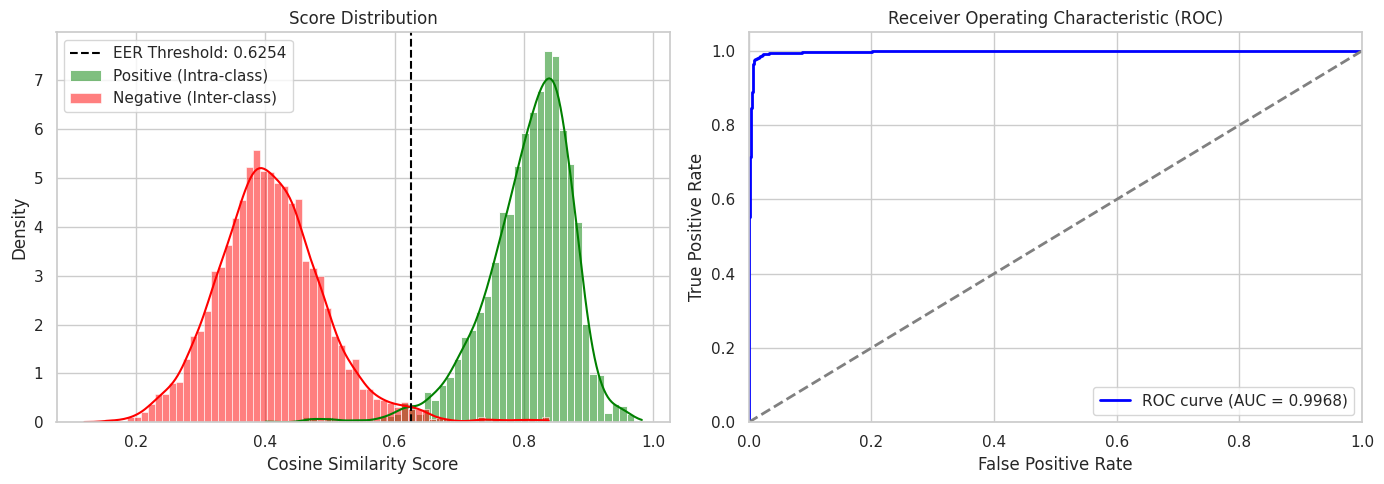

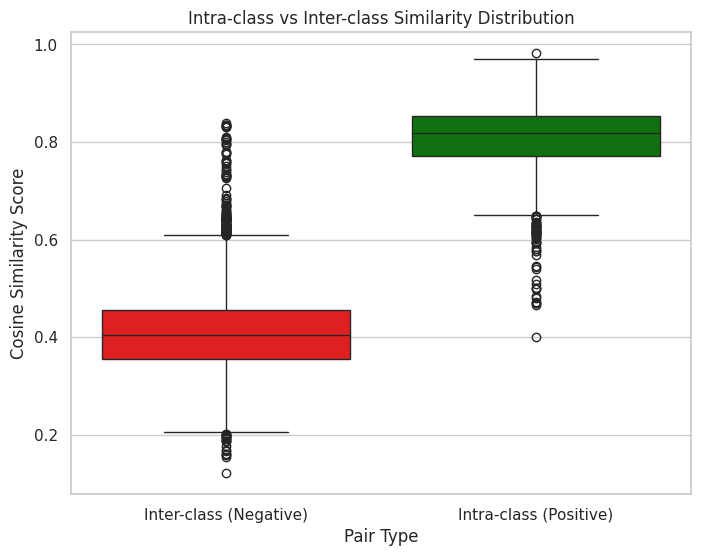

In [23]:
# ===== Score Distribution Analysis =====
pos_scores = scores_arr[labels_arr == 1]
neg_scores = scores_arr[labels_arr == 0]

print("Score Distribution:")
print(f"  Positive pairs ({len(pos_scores)}):")
print(f"    mean={pos_scores.mean():.4f}, std={pos_scores.std():.4f}")
print(f"    min={pos_scores.min():.4f}, max={pos_scores.max():.4f}")
print(f"  Negative pairs ({len(neg_scores)}):")
print(f"    mean={neg_scores.mean():.4f}, std={neg_scores.std():.4f}")
print(f"    min={neg_scores.min():.4f}, max={neg_scores.max():.4f}")
print(f"  Separation: {pos_scores.mean() - neg_scores.mean():.4f}")

# ---------------- BỔ SUNG VISUALIZE ---------------- #
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    from sklearn.metrics import roc_curve, auc
    
    # Tạo DataFrame để sử dụng với seaborn
    df = pd.DataFrame({"score": scores_arr, "label": labels_arr})
    
    # Tính toán ROC và AUC bằng sklearn (chỉ dùng cho Visualize ROC Curve)
    fpr, tpr, thresholds_roc = roc_curve(labels_arr, scores_arr, pos_label=1)
    roc_auc = auc(fpr, tpr)
    
    sns.set_theme(style="whitegrid")
    
    # --- Figure 1: Score Distribution (Histogram) & ROC Curve ---
    plt.figure(figsize=(14, 5))
    
    # 1. Score Distribution
    plt.subplot(1, 2, 1)
    sns.histplot(data=df[df['label']==1], x='score', color='green', label='Positive (Intra-class)', kde=True, stat='density', alpha=0.5)
    sns.histplot(data=df[df['label']==0], x='score', color='red', label='Negative (Inter-class)', kde=True, stat='density', alpha=0.5)
    # Dùng threshold đã tính từ hàm compute_eer ban đầu của bạn
    plt.axvline(threshold, color='black', linestyle='--', label=f'EER Threshold: {threshold:.4f}')
    plt.title('Score Distribution')
    plt.xlabel('Cosine Similarity Score')
    plt.ylabel('Density')
    plt.legend()
    
    # 2. ROC Curve
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    
    plt.tight_layout()
    plt.savefig('eer_analysis.png', dpi=150)
    plt.show()

    # --- Figure 2: Boxplot ---
    plt.figure(figsize=(8, 6))
    sns.boxplot(
        x='label', 
        y='score', 
        hue='label', 
        data=df, 
        palette={1: 'green', 0: 'red', '1': 'green', '0': 'red'}, 
        legend=False
    )
    plt.xticks([0, 1], ['Inter-class (Negative)', 'Intra-class (Positive)'])
    plt.title('Intra-class vs Inter-class Similarity Distribution')
    plt.ylabel('Cosine Similarity Score')
    plt.xlabel('Pair Type')
    plt.savefig('intra_inter_boxplot.png', dpi=150)
    plt.show()

except ImportError:
    print("(matplotlib, seaborn hoặc sklearn chưa được cài đặt, bỏ qua phần visualize)")